In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [40]:
#Считайте датасет из файла train.csv (это данные о выживаемости на Титанике) - 1 балл
df = pd.read_csv('train.csv')
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


<function matplotlib.pyplot.show(close=None, block=None)>

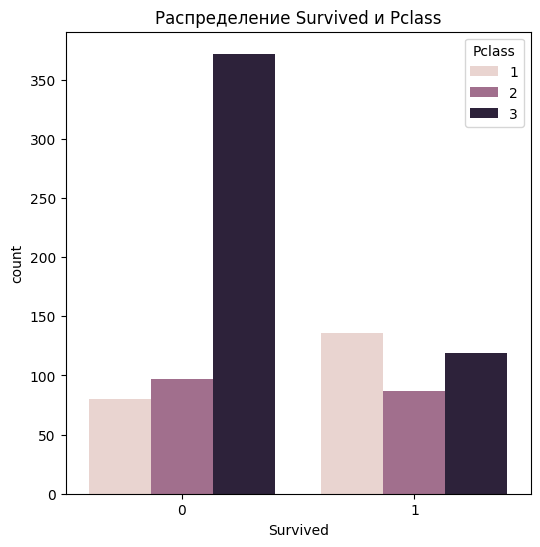

In [41]:
#Визуализируйте распределение значений признаков
plt.figure(figsize=[6,6])
sns.countplot(data=df, x='Survived', hue = 'Pclass')
plt.title('Распределение Survived и Pclass')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

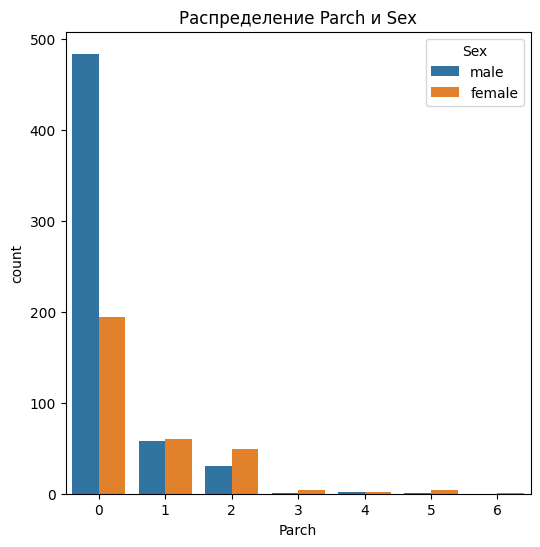

In [42]:
plt.figure(figsize=[6,6])
sns.countplot(data=df, x='Parch', hue = 'Sex')
plt.title('Распределение Parch и Sex')
plt.show

Parch в датасете Titanic — это «количество родителей или детей» (Parents/Children), которые были у пассажира на борту.

Формально:

Parch = число родителей + число детей пассажира, находившихся с ним на корабле.


/tmp/ipykernel_4008/3224395342.py:4: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



<function matplotlib.pyplot.show(close=None, block=None)>

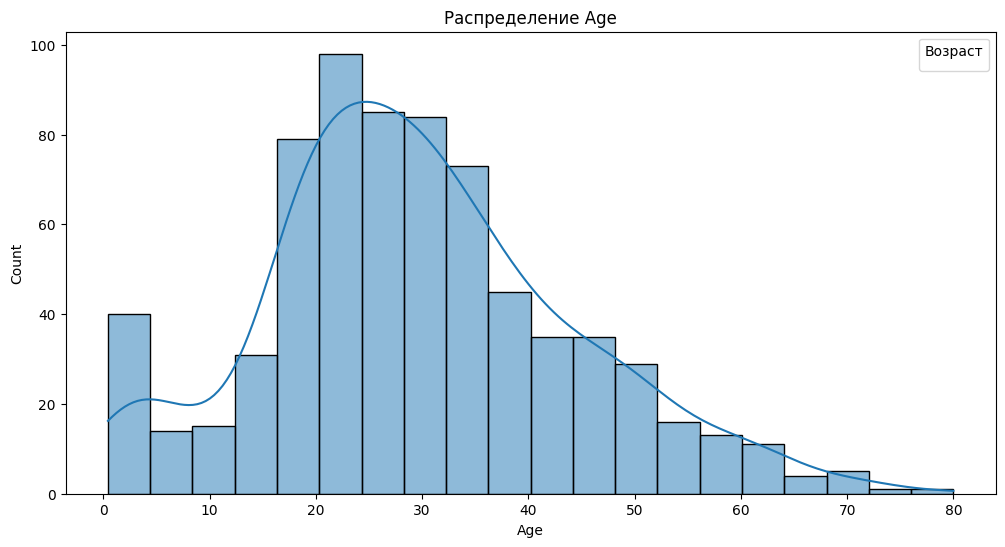

In [43]:
plt.figure(figsize=[12,6])
sns.histplot(data=df, x='Age', bins=20, kde=True)
plt.title('Распределение Age')
plt.legend(title='Возраст')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

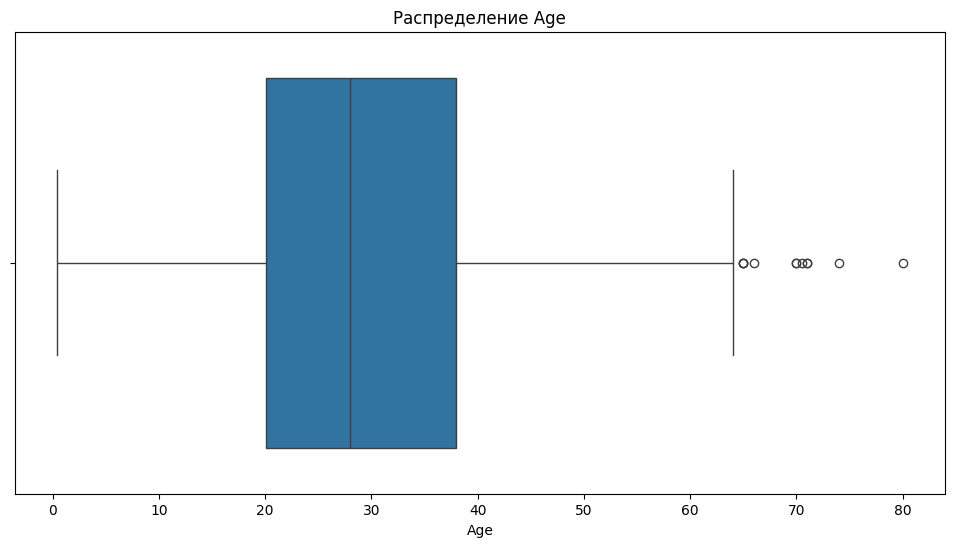

In [44]:
#Постройте график типа boxplot для столбца Age
plt.figure(figsize=[12,6])
sns.boxplot(data= df, x= 'Age')
plt.title('Распределение Age')
plt.show

Проинтепретируйте полученный график - 1 балл

Полученный график показывает распределение пассажиров «Титаника» по возрастам. Мы видим разброс признака от чуть более 0 до 80 лет. Большая часть пассажиров приходится на интервал от 20 до 38 лет. 25-й персентиль — 20 лет (т.е. 25% пассажиров моложе или ровно 20 лет), 75-й персентиль — 38 лет (т.е. 75% пассажиров моложе или ровно 38 лет). Медианный возраст — 28 лет. В правой части распределения встречаются выбросы - единичные пассажиры старшего возраста: около 70, 73 и 80 лет.




In [45]:
#Постройте график типа pie chart для переменных Survived, Pclass, подпишите доли в процентах - 1 балл

count = df['Survived'].value_counts()
count

,count
Survived,
0,549
1,342


([<matplotlib.patches.Wedge at 0x7d3b6e320050>,
 [Text(-0.39257494735793463, 1.0275626067091557, 'Погибшие'),
  Text(0.3925749146953058, -1.0275626191877425, 'Выжившие')],
 [Text(-0.21413178946796432, 0.5604886945686304, '61.6%'),
  Text(0.21413177165198496, -0.5604887013751322, '38.4%')])

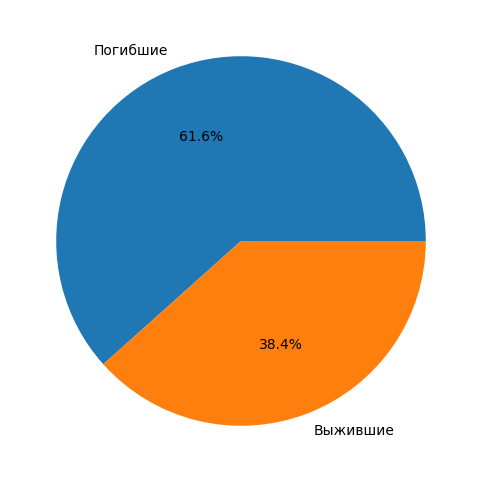

In [46]:
labels = ['Погибшие', 'Выжившие']
plt.figure(figsize=[10,6])
plt.pie(
    count,
    labels = labels,
    autopct='%1.1f%%'

)

In [47]:
df['Pclass'].unique()

array([3, 1, 2])

In [48]:
count = df['Pclass'].value_counts().sort_index()
count

,count
Pclass,
1,216
2,184
3,491


In [49]:
count.index

Index([1, 2, 3], dtype='int64', name='Pclass')

In [50]:
labels = [f'Class {c}' for c in count.index]
labels

['Class 1', 'Class 2', 'Class 3']

([<matplotlib.patches.Wedge at 0x7d3b6e35cb90>,
 [Text(0.7961073888092188, 0.7590869683266651, 'Class 1'),
  Text(-0.6221676258736402, 0.9071424614219965, 'Class 2'),
  Text(-0.17571587166875585, -1.0858747314693762, 'Class 3')],
 [Text(0.43424039389593755, 0.41404743726909, '24.2%'),
  Text(-0.3393641595674401, 0.49480497895745257, '20.7%'),
  Text(-0.09584502091023045, -0.592295308074205, '55.1%')])

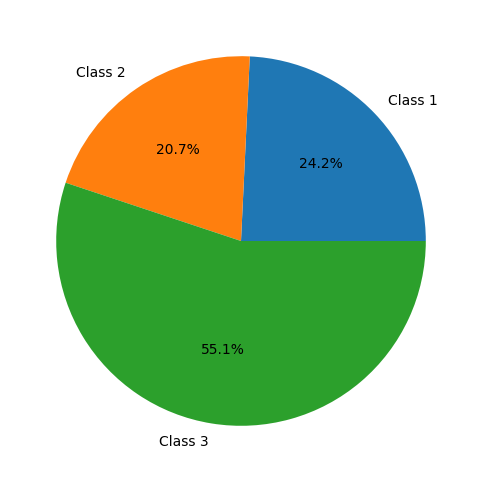

In [51]:
plt.figure(figsize=[10,6])
plt.pie(
    count,
    labels = labels,
    autopct='%1.1f%%'

)

In [52]:
#Постройте график типа pairplot для всех числовых переменных датасета - 1 балл
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [53]:
numbers_var = df.select_dtypes(include= 'number')
numbers_var.columns
numbers_var=numbers_var[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]

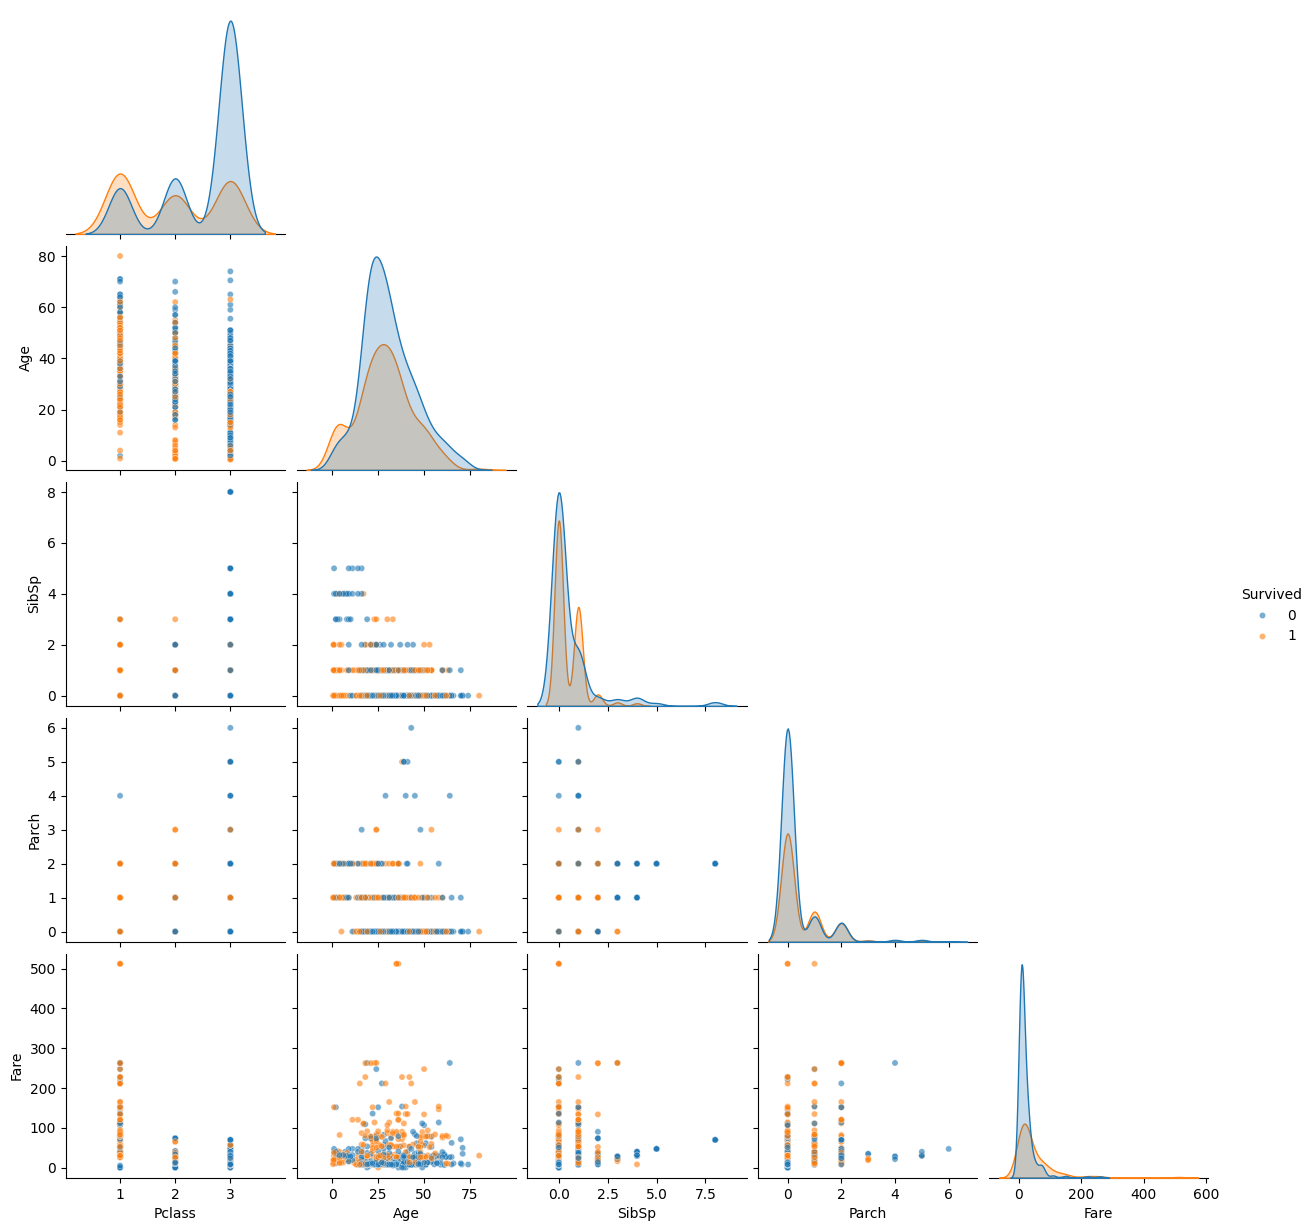

In [54]:
sns.pairplot(
    numbers_var,
    hue='Survived',
    corner=True,
 #   diag_kind='hist',   # 'hist' или 'kde' для диагоналей
   plot_kws={'alpha': 0.6, 's': 20},  # прозрачность и размер точек

)
plt.show()

In [55]:
#Постройте интерактивный sunburst plot (визуализация иерархических данных) с помощью plotly.
#На первом уровне иерархии - количество пассажиров в каждом из классов, а на втором количество женщин/мужчин в этом классе - 2 балла

In [56]:
import plotly.express as px

data = df.copy()

data['Pclass'] = data['Pclass'].map({
    1: '1 класс',
    2: '2 класс',
    3: '3 класс'
})

data['Sex'] = data['Sex'].map({
    'male': 'Мужчины',
    'female': 'Женщины'
})

df_Pclass_Sex = px.sunburst(
    data,
    path=['Pclass', 'Sex'],
#    color='Sex',  # цвет секторов зависит от пола

    title='Анализ количества пассажиров по классу и полу'
)

df_Pclass_Sex.update_traces(
    textinfo='label+value+percent parent'
)

df_Pclass_Sex.update_layout(
    width=900,   # ширина в пикселях
    height=700   # высота в пикселях
)

df_Pclass_Sex.show()